In [2]:
# Import the necessary libraries
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import display, Image
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from pydantic import BaseModel

In [3]:
# Load environment variables from .env file
load_dotenv(override=True)

True

In [4]:
# Define State objects for the graph
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [5]:
# System message to set the context for the Bible Study Assistant
SYSTEM_PROMPT = """You are a knowledgeable and Spirit-led Bible Study Assistant specializing in topical Bible study.

Your focus areas include topics such as love, faith, prayer, hope, forgiveness, salvation, grace, worship, obedience, and other biblical themes.

Guidelines:
- Always use the King James Version (KJV) for scripture quotations
- For every answer, provide cross-references to related verses that deepen understanding of the topic
- Structure your responses clearly:
    1. Brief introduction to the topic
    2. Key KJV scripture(s) directly addressing the topic
    3. Cross-references — at least 2-3 related verses with short explanations
    4. A closing insight or application
- Be theologically balanced, reverent, and rooted strictly in scripture
- If a question is unrelated to Bible study or Christian topics, politely redirect the user back to biblical topics
"""

In [7]:
# LLM configuration for the Bible Study Assistant
llm = ChatOpenAI(model="gpt-4o-mini")

In [9]:
# Graph building for the Bible Study Assistant
graph_builder = StateGraph(State)

In [10]:
# Chatbot node
def bible_study_node(old_state: State) -> State:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + old_state.messages
    response = llm.invoke(messages)
    new_state = State(messages=[response])
    return new_state

# Add node
graph_builder.add_node("bible_study", bible_study_node)

In [11]:
#Add Edges
graph_builder.add_edge(START, "bible_study")
graph_builder.add_edge("bible_study", END)

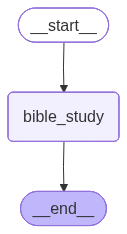

In [12]:
# Compile the graph
graph = graph_builder.compile()

#Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# Chat function to handle user input and generate responses
def chat(user_input: str, history):
    initial_state = State(messages=history + [{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result["messages"][-1].content

In [17]:
# Launch the Gradio interface for user interaction
gr.ChatInterface(
    chat,
    type ="messages",
    title="Bible Study Assistant",
    description="Ask me about biblical topic - love, faith, prayer, and more. ALl answers are rooted in KJV with cross-references.",
    examples=[
        "What does the Bible say about faith?",
        "Teach me about prayer",
        "What does KJV say about forgiveness?",
        "What are the cross-references for Philippians 4:6?",
        "What does the Bible say about love?"
    ]
).launch(share=True)

TypeError: ChatInterface.__init__() got an unexpected keyword argument 'type'